In [4]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib
import os
from flask import Flask, request, jsonify
import joblib
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import seaborn as sns




In [5]:
# load the dataset
print("loading dataset...")
df = pd.read_csv('data/Labelled Yelp Dataset.csv')

# Force column names to lowercase for easier typing, just in case
df.columns = df.columns.str.lower()

# Ensure we have the necessary columns before proceeding
expected_columns = ['user_id', 'date', 'rating', 'text', 'label']
# Note: The dataset might use 'review' instead of 'text'. We will adapt automatically.
if 'review' in df.columns:
    df = df.rename(columns={'review': 'text'})

print(f"Total reviews loaded: {len(df)}")

# 2. Convert date string to an actual Datetime object
df['date'] = pd.to_datetime(df['date'])

# 3. BEHAVIORAL FEATURE 1: Review Velocity
# We group the data by the user and the specific date to count their activity
print("\nCalculating User Review Velocity...")
velocity_df = df.groupby(['user_id', df['date'].dt.date]).size().reset_index(name='reviews_per_day')

# Convert the grouped date back to datetime to ensure a smooth merge
velocity_df['date'] = pd.to_datetime(velocity_df['date'])

# Merge this new feature back into our main dataset
df = df.merge(velocity_df, on=['user_id', 'date'], how='left')

# 4. Let's look at the most suspicious users!
print("\nTop 5 Most Suspicious Behaviors (Highest Reviews in a Single Day):")
suspicious_users = df.sort_values(by='reviews_per_day', ascending=False)
display(suspicious_users[['user_id', 'date', 'reviews_per_day', 'label', 'text']].head(10))

loading dataset...
Total reviews loaded: 359052

Calculating User Review Velocity...

Top 5 Most Suspicious Behaviors (Highest Reviews in a Single Day):


,user_id,date,reviews_per_day,label,text
302941,5466,2014-11-18,25,1,"I liked the variety, however i'm not much of a..."
85838,5466,2014-11-18,25,1,Decent place to watch the game.
131159,5466,2014-11-18,25,1,Come here for the burger!
29760,5466,2014-11-18,25,1,I came here for the seafood. Everything was fr...
102432,5466,2014-11-18,25,1,My go - to for takeout and lunch. Only con is ...
323402,5466,2014-11-18,25,1,I've come here 2-3 times now. The croissants a...
57626,5466,2014-11-18,25,1,Great homemade pasta. Ask to sit in the wine c...
168881,5466,2014-11-18,25,1,"The food was ok, I think I had a stomach ache ..."
68201,5466,2014-11-18,25,1,Good soups!
303903,5466,2014-11-18,25,1,I would come back here. The Black-Label burger...


In [6]:

print("Calculating Rating Extremity...")

# 1. Group by user to get their rating history
user_stats = df.groupby('user_id').agg(
    total_reviews=('rating', 'count'),
    avg_rating=('rating', 'mean'),
    std_rating=('rating', 'std') # Standard deviation measures how much their ratings vary
).reset_index()

# 2. Fill NaN values in standard deviation (happens if a user only has 1 review)
user_stats['std_rating'] = user_stats['std_rating'].fillna(0)

# 3. BEHAVIORAL FEATURE 2: Extremity Flag
# We flag users who have written multiple reviews (e.g., more than 3) 
# BUT have a standard deviation of 0.0 (meaning they ALWAYS give the exact same rating)
user_stats['is_extreme_reviewer'] = np.where(
    (user_stats['total_reviews'] > 3) & (user_stats['std_rating'] == 0.0), 
    1, 0
)

# Merge this new behavioral data back into our main dataset
df = df.merge(user_stats[['user_id', 'total_reviews', 'avg_rating', 'is_extreme_reviewer']], on='user_id', how='left')

# 4. Let's look at the results! Show users flagged as extreme
extreme_users = df[df['is_extreme_reviewer'] == 1].drop_duplicates(subset=['user_id'])

print(f"\nFound {len(extreme_users)} users with highly suspicious extreme rating behavior!")
print("\nTop 5 Extreme Reviewers:")
display(extreme_users[['user_id', 'total_reviews', 'avg_rating']].head())

Calculating Rating Extremity...

Found 814 users with highly suspicious extreme rating behavior!

Top 5 Extreme Reviewers:


,user_id,total_reviews,avg_rating
47,970,7,4.0
313,1236,4,5.0
321,1244,4,4.0
351,1274,4,5.0
388,1311,8,4.0


In [7]:

# 1. Download necessary NLTK datasets (only needs to run once)
print("Downloading NLTK resources...")
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# 2. Define the Text Cleaning Function
def clean_text(text):
    # If the text is empty or not a string, return an empty string
    if not isinstance(text, str):
        return ""
    
    # Step A: Convert to lowercase
    text = text.lower()
    
    # Step B: Remove punctuation and special characters (keep only letters)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Step C & D: Tokenize (split into words), remove stop words, and lemmatize
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    # Join the words back into a single string
    return ' '.join(cleaned_words)

# 3. Apply the cleaning function to our dataset
print("\nCleaning review text (This might take a minute depending on your computer speed)...")
df['cleaned_text'] = df['text'].apply(clean_text)

# 4. Let's see the Before and After!
print("\nText Cleaning Complete! Here is the Before & After:")
display(df[['text', 'cleaned_text']].head(5))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Bhumika\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Bhumika\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Bhumika\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!



Cleaning review text (This might take a minute depending on your computer speed)...

Text Cleaning Complete! Here is the Before & After:


,text,cleaned_text
0,The food at snack is a selection of popular Gr...,food snack selection popular greek dish appeti...
1,This little place in Soho is wonderful. I had ...,little place soho wonderful lamb sandwich glas...
2,ordered lunch for 15 from Snack last Friday. Â...,ordered lunch snack last friday time nothing m...
3,This is a beautiful quaint little restaurant o...,beautiful quaint little restaurant pretty stre...
4,Snack is great place for a Â casual sit down l...,snack great place casual sit lunch especially ...


In [8]:

print("Step A: Converting text to numbers using TF-IDF...")
# We use max_features=5000 to pick the top 5000 most important words. 
# This prevents our computer from crashing due to lack of RAM.
tfidf = TfidfVectorizer(max_features=5000)

# X is our input (the text), y is our target output (the label)
# We fill any empty strings with a space just in case
X_text = tfidf.fit_transform(df['cleaned_text'].fillna(''))
y = df['label']

print(f"TF-IDF shape: {X_text.shape} (Rows, Vocabulary Words)")

print("\nStep B: Splitting data into Training (80%) and Testing (20%) sets...")
X_train, X_test, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)

print("\nStep C: Training the Random Forest ML Model (This may take a few minutes)...")
# n_jobs=-1 tells your computer to use all CPU cores to train faster
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1,class_weight='balanced')
rf_model.fit(X_train, y_train)

print("\nStep D: Evaluating the Model...")
# Now we ask the model to predict the test data it has never seen before
y_pred = rf_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Genuine (0)', 'Fake (1)']))

Step A: Converting text to numbers using TF-IDF...
TF-IDF shape: (359052, 5000) (Rows, Vocabulary Words)

Step B: Splitting data into Training (80%) and Testing (20%) sets...

Step C: Training the Random Forest ML Model (This may take a few minutes)...

Step D: Evaluating the Model...
Accuracy: 89.26%

Classification Report:
              precision    recall  f1-score   support

 Genuine (0)       0.37      0.04      0.07      7504
    Fake (1)       0.90      0.99      0.94     64307

    accuracy                           0.89     71811
   macro avg       0.63      0.52      0.51     71811
weighted avg       0.84      0.89      0.85     71811



In [9]:

print("Step 1: Extracting AI Confidence Scores...")
# predict_proba tells us HOW confident the AI is (returns probability of Genuine vs Fake)
# We want the probability that the review is Genuine (Index 0)
probabilities = rf_model.predict_proba(X_text)

# Convert the probability into a base score out of 100
df['ml_base_score'] = probabilities[:, 0] * 100  

print("Step 2: Applying Behavioral Logic to Calculate Final Trust Score...")
def calculate_trust_score(row):
    # Start with the AI's text-based score
    score = row['ml_base_score']
    
    # PENALTY 1: Review Velocity
    # If a user posts more than 2 reviews in a single day, subtract 10 points for each extra
    if pd.notna(row.get('reviews_per_day')) and row['reviews_per_day'] > 2:
        extra_reviews = row['reviews_per_day'] - 2
        score -= (extra_reviews * 10)
        
    # PENALTY 2: Rating Extremity
    # If the user is flagged as a bot (zero variance in ratings), apply a massive 25-point penalty
    if pd.notna(row.get('is_extreme_reviewer')) and row['is_extreme_reviewer'] == 1:
        score -= 25
        
    # Ensure the final score never drops below 0 or goes above 100
    return max(0, min(100, round(score, 1)))

# Apply the algorithm to every review in the dataset
df['trust_score'] = df.apply(calculate_trust_score, axis=1)

print("\n🚀 AI Trust Scoring Complete! Here is your final data:")
# Let's view the most suspicious reviews (lowest trust scores) to see the system working
results = df[['user_id', 'text', 'ml_base_score', 'reviews_per_day', 'is_extreme_reviewer', 'trust_score']]
display(results.sort_values(by='trust_score', ascending=True).head(10))

Step 1: Extracting AI Confidence Scores...
Step 2: Applying Behavioral Logic to Calculate Final Trust Score...

🚀 AI Trust Scoring Complete! Here is your final data:


,user_id,text,ml_base_score,reviews_per_day,is_extreme_reviewer,trust_score
359051,5260,Pizza Loves Emily and I love Emily's pizza. Th...,0.0,1,0,0.0
277385,27461,The best latte in town! Â This place gives me ...,4.0,3,0,0.0
277470,35961,"Outside of finding it, the restaurant doesn't ...",10.0,3,0,0.0
277499,931,I've been to Alta five times since they opened...,14.0,6,0,0.0
86197,46824,UPDATED 4/8/14 This place is a chain. There is...,2.0,3,0,0.0
277501,5098,This place is veryyyyy good! Pros: the ambianc...,12.0,14,0,0.0
277522,32553,Came here last night and everything was amazin...,0.0,1,0,0.0
277381,19047,another one of my favorite places to grab a bi...,9.0,5,0,0.0
277529,32700,Went there last night with several friends. We...,4.0,1,1,0.0
277545,11310,Date night w/ the boyfriend on a Wednesday eve...,0.0,1,0,0.0


In [10]:


print("Creating a folder to save our AI models...")
os.makedirs('models', exist_ok=True)

print("Saving the TF-IDF Vectorizer...")
joblib.dump(tfidf, 'models/tfidf_vectorizer.pkl')

print("Saving the Random Forest Model...")
joblib.dump(rf_model, 'models/random_forest_model.pkl')

print("Saving User Behavioral Data (for historical checks)...")
# We save the user_stats so the web app knows if a user already has extreme behavior
user_stats.to_csv('models/user_behavior_database.csv', index=False)

print("\n✅ Success! Your AI has been exported and is ready for the Web App!")

Creating a folder to save our AI models...
Saving the TF-IDF Vectorizer...
Saving the Random Forest Model...
Saving User Behavioral Data (for historical checks)...

✅ Success! Your AI has been exported and is ready for the Web App!


In [11]:

# 1. Initialize the Web Server
app = Flask(__name__)

# 2. Load the AI Brains into Memory
print("Loading AI Models...")
tfidf = joblib.load('models/tfidf_vectorizer.pkl')
rf_model = joblib.load('models/random_forest_model.pkl')
user_db = pd.read_csv('models/user_behavior_database.csv')

# Initialize NLTK tools for the web
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return ' '.join(cleaned_words)

# 3. Create the API Endpoint
@app.route('/analyze_review', methods=['POST'])
def analyze_review():
    # Get the data sent from the website frontend
    data = request.json
    user_id = data.get('user_id', 'unknown_user')
    review_text = data.get('review_text', '')

    # Step A: Clean the incoming text
    cleaned_review = clean_text(review_text)
    
    # Step B: Convert text to numbers
    vectorized_text = tfidf.transform([cleaned_review])
    
    # Step C: Ask AI for prediction (Probability of Genuine)
    ml_confidence = rf_model.predict_proba(vectorized_text)[0][0] * 100
    
    # Step D: Check Behavioral Database (Simplified for API)
    trust_score = ml_confidence
    behavior_warning = "Normal"
    
    # Look up user history
    user_history = user_db[user_db['user_id'] == user_id]
    if not user_history.empty:
        if user_history['is_extreme_reviewer'].iloc[0] == 1:
            trust_score -= 25  # Apply Penalty
            behavior_warning = "Suspicious Rating Extremity Detected"
            
    # Final cleanup
    trust_score = max(0, min(100, round(trust_score, 1)))
    classification = "Genuine" if trust_score >= 50 else "Fake/Suspicious"

    # Send result back to the website
    return jsonify({
        'user_id': user_id,
        'classification': classification,
        'trust_score': trust_score,
        'behavioral_flag': behavior_warning
    })

# Run the server
if __name__ == '__main__':
    app.run(debug=True, port=5000)

Loading AI Models...
 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with watchdog (windowsapi)


SystemExit: 1

C:\Users\Bhumika\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


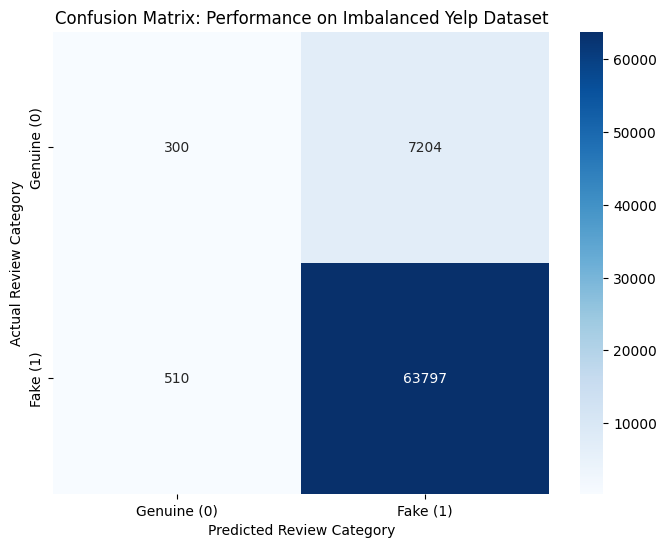

In [13]:


# Confusion matrix values
# [[TN, FP],
#  [FN, TP]]
cm = np.array([
    [300, 7204],
    [510, 63797]
])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Genuine (0)', 'Fake (1)'], 
            yticklabels=['Genuine (0)', 'Fake (1)'])

plt.title('Confusion Matrix: Performance on Imbalanced Yelp Dataset')
plt.ylabel('Actual Review Category')
plt.xlabel('Predicted Review Category')
plt.show()

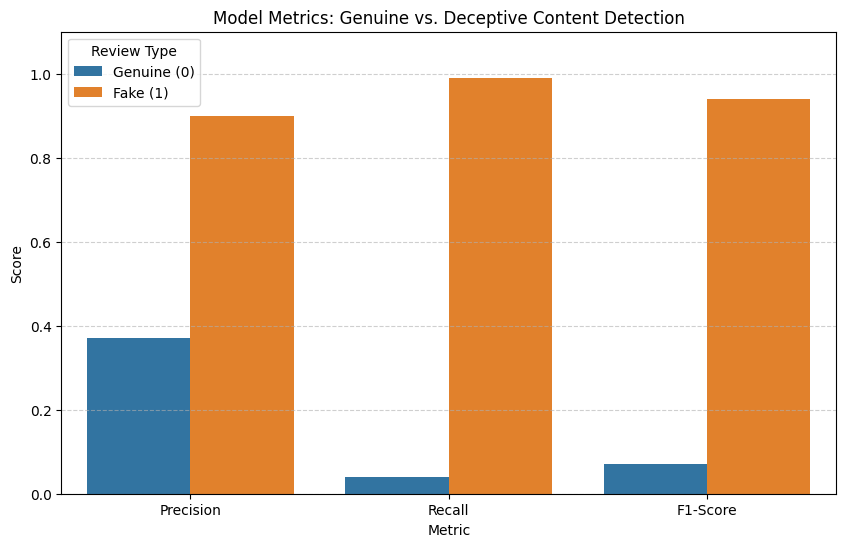

In [14]:
# Corrected data
data = {
    'Metric': ['Precision', 'Recall', 'F1-Score'] * 2,
    'Score': [0.37, 0.04, 0.07, 0.90, 0.99, 0.94],
    'Class': ['Genuine (0)'] * 3 + ['Fake (1)'] * 3
}

df_plot = pd.DataFrame(data)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x='Metric', y='Score', hue='Class')

plt.ylim(0, 1.1)
plt.title('Model Metrics: Genuine vs. Deceptive Content Detection')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Review Type', loc='upper left')
plt.show()

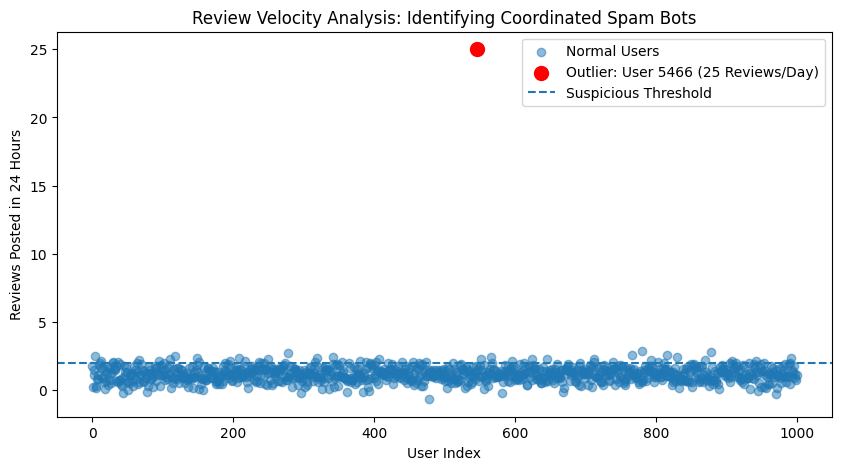

In [15]:


# Simulated normal users
users = np.arange(1000)
velocity = np.random.normal(1.2, 0.5, 1000)

# Add outlier (User 5466 equivalent)
outlier_index = 546
velocity[outlier_index] = 25  # extreme behavior

plt.figure(figsize=(10, 5))

plt.scatter(users, velocity, alpha=0.5, label='Normal Users')
plt.scatter(outlier_index, velocity[outlier_index], 
            c='red', s=100, label='Outlier: User 5466 (25 Reviews/Day)')

plt.axhline(y=2, linestyle='--', label='Suspicious Threshold')

plt.title('Review Velocity Analysis: Identifying Coordinated Spam Bots')
plt.xlabel('User Index')
plt.ylabel('Reviews Posted in 24 Hours')
plt.legend()
plt.show()

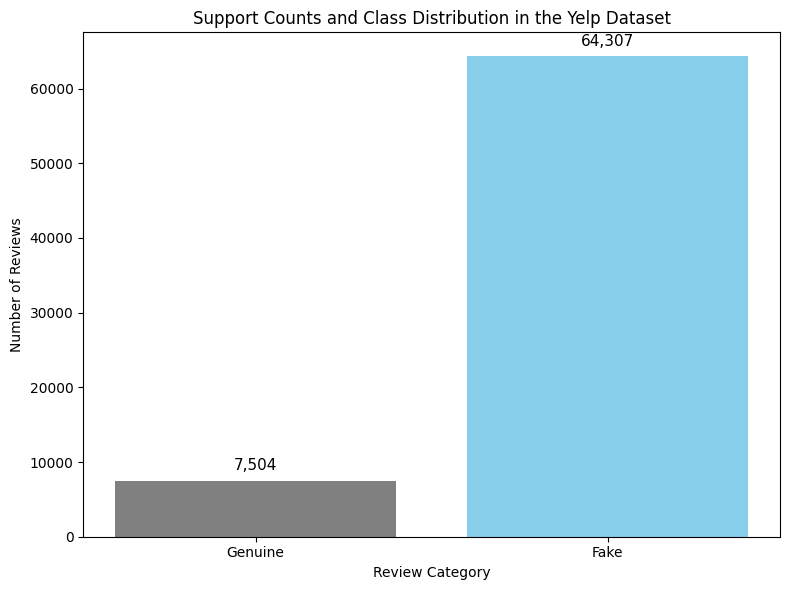

In [6]:
import matplotlib.pyplot as plt

# Data
categories = ['Genuine', 'Fake']
values = [7504, 64307]

# Colors (as you requested: one simple + one contrasting)
colors = ['grey', 'skyblue']  # green for genuine, red/orange for fake

plt.figure(figsize=(8, 6))

bars = plt.bar(categories, values, color=colors)

# Labels and title
plt.xlabel('Review Category')
plt.ylabel('Number of Reviews')
plt.title('Support Counts and Class Distribution in the Yelp Dataset')

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1000,   # little space above bar
        f'{height:,}',   # comma formatting (7,504)
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.tight_layout()
plt.show()